In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv("i40 (datos).csv")

# Definimos las columnas numéricas con sus nombres reales (incluyendo unidades)
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

In [ ]:
# Visualizar los primeros registros del dataframa
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [5]:
# Vemos información sobre el dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  object 
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  object 
dtypes: float64(3), int64(4), object(2)
memory usage: 1021.1+ KB


In [7]:
# Consultamos forma del Datasheet
df.shape

(14521, 9)

In [8]:
print("Resumen estadístico:")
df[cols].describe().T

Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
air_temp [K],14481.0,300.478975,1.952737,295.3,298.90,300.60,302.20,304.5
process_temp [K],14521.0,310.165287,1.329586,305.7,309.20,310.32,311.09,313.8
speed [RPM],14521.0,1513.389436,313.604170,-1.0,1354.00,1423.00,1561.00,2886.0
torque [Nm],14521.0,44.955809,14.226641,3.8,35.99,46.70,55.00,76.6
tool_wear [min],14521.0,124.921700,70.105992,0.0,64.00,127.00,193.00,253.0


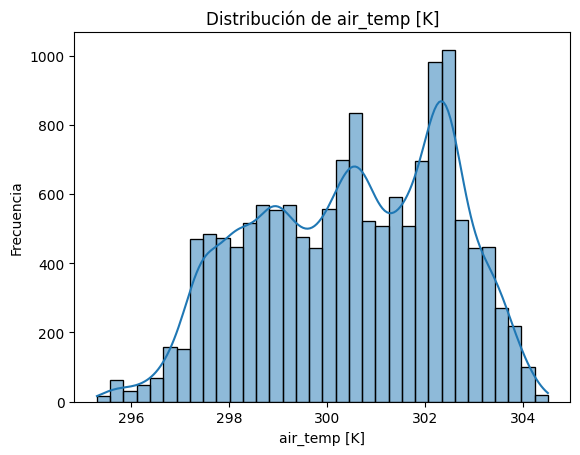

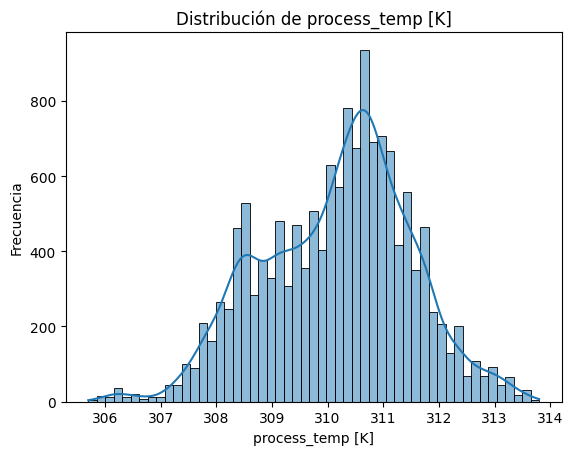

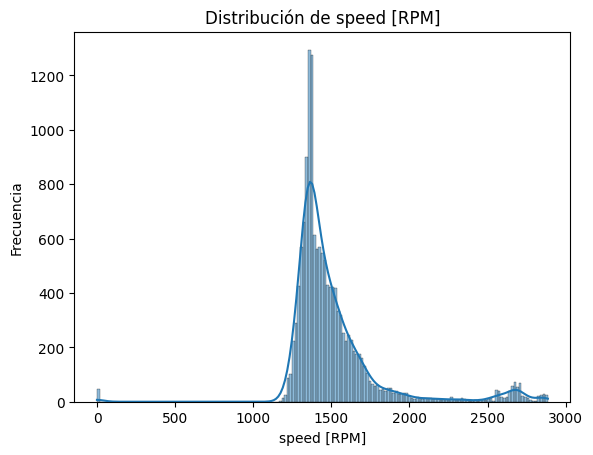

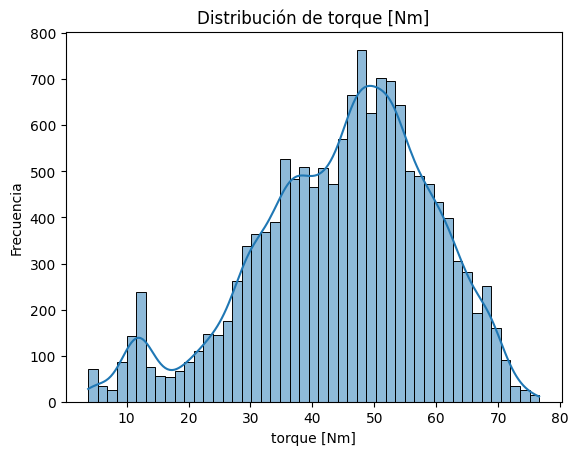

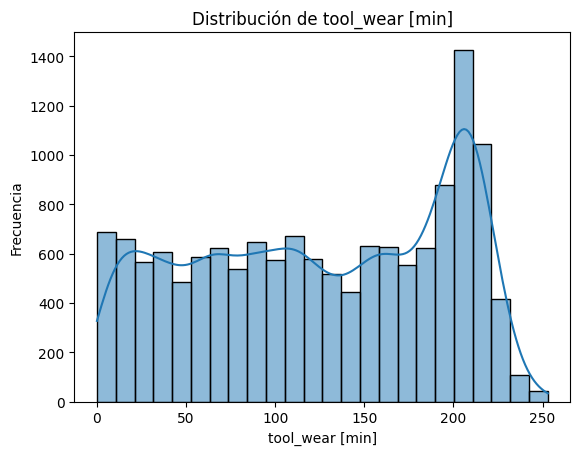

In [9]:
# Distribución de var
for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

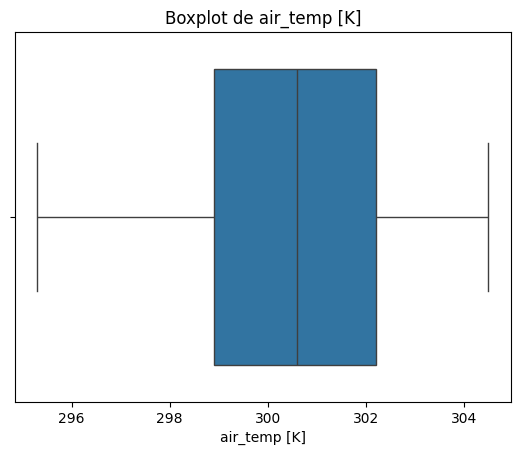

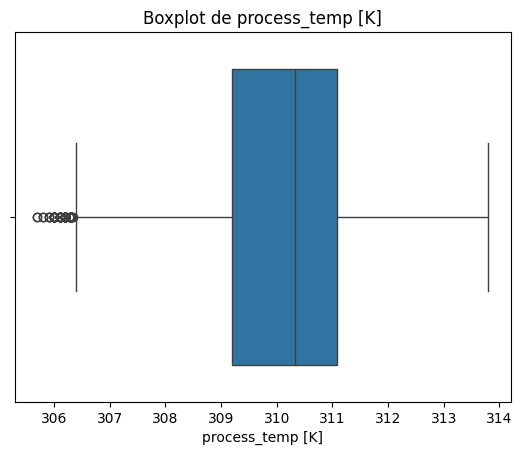

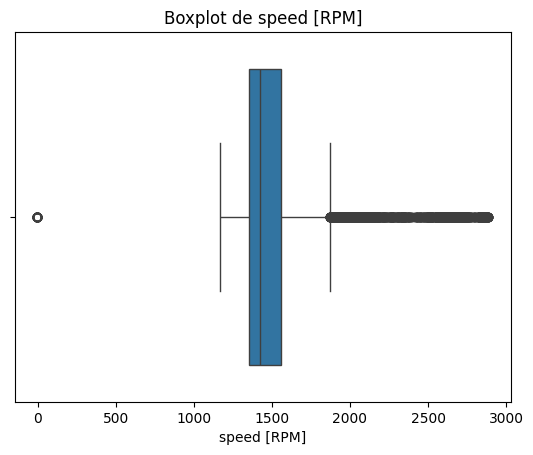

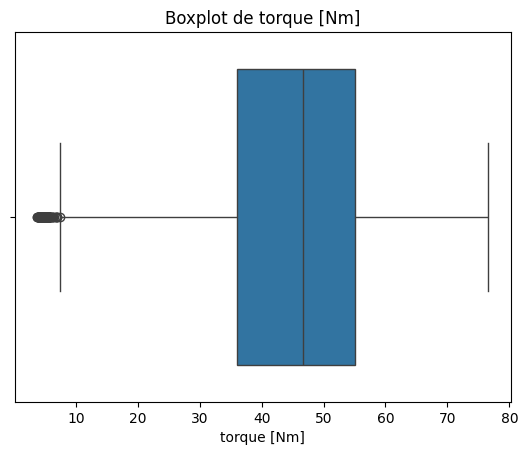

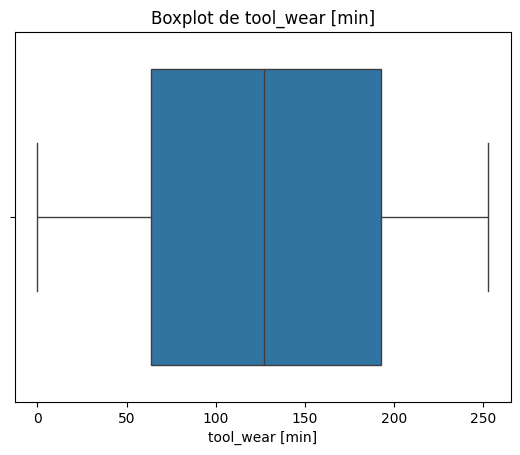

In [10]:
# Medidas de dispersión
# Boxplots. Muestra la distribución de los datos, identificando mediana, cuartiles y valores extremos (ver presentación de la catedra)
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [11]:
# Proporciones
# Var objetivo, cuenta los casos
df['target'].value_counts()

,count
target,
failure,7482
normal,7039


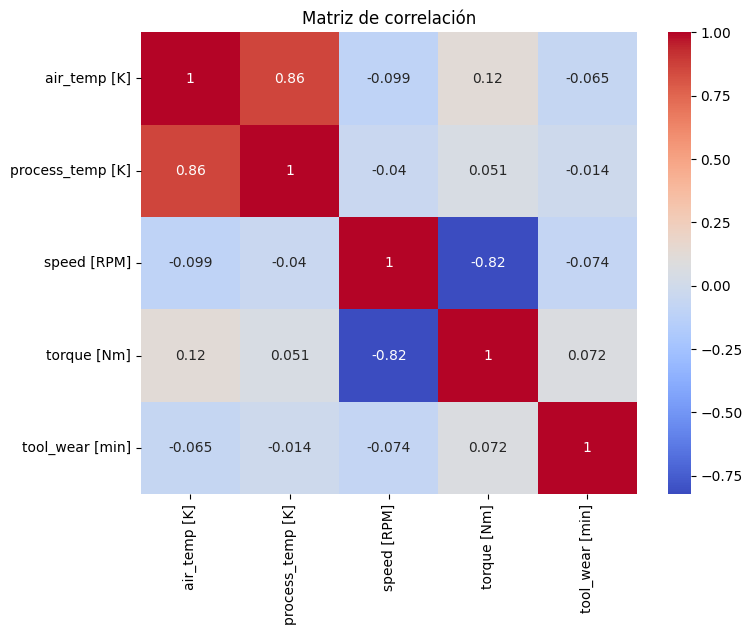

In [12]:
# Correlación entre var
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

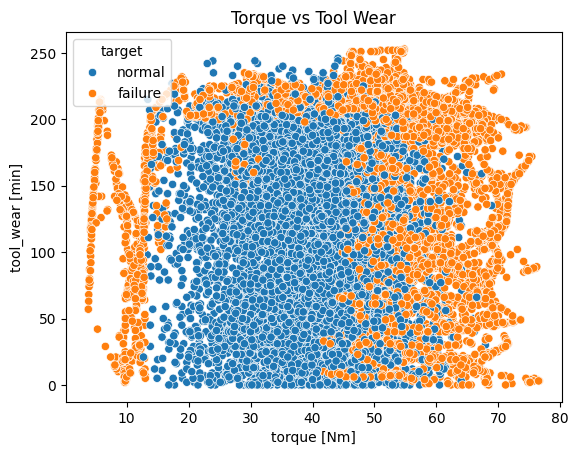

In [15]:
# Relación entre var
sns.scatterplot(x='torque [Nm]', y='tool_wear [min]', hue='target', data=df)
plt.title("Torque vs Tool Wear")
plt.show()

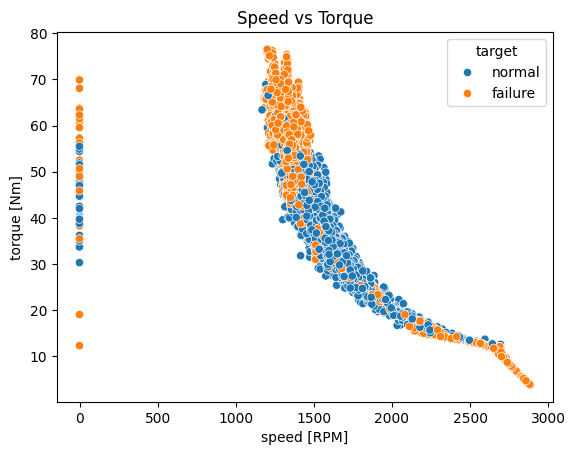

In [17]:
# Relación entre var
sns.scatterplot(x='speed [RPM]', y='torque [Nm]', hue='target', data=df)
plt.title("Speed vs Torque")
plt.show()

In [18]:
# Analisis de variables
import pandas as pd
df = pd.read_csv("i40 (datos).csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  object 
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  object 
dtypes: float64(3), int64(4), object(2)
memory usage: 1021.1+ KB


,idx,parent_device_id,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min]
count,14521.000000,14521.000000,14481.000000,14521.000000,14521.000000,14521.000000,14521.000000
mean,7260.000000,9802.076510,300.478975,310.165287,1513.389436,44.955809,124.921700
std,4191.995965,5572.531866,1.952737,1.329586,313.604170,14.226641,70.105992
min,0.000000,0.000000,295.300000,305.700000,-1.000000,3.800000,0.000000
25%,3630.000000,4982.000000,298.900000,309.200000,1354.000000,35.990000,64.000000
50%,7260.000000,9956.000000,300.600000,310.320000,1423.000000,46.700000,127.000000
75%,10890.000000,14624.000000,302.200000,311.090000,1561.000000,55.000000,193.000000
max,14520.000000,19320.000000,304.500000,313.800000,2886.000000,76.600000,253.000000


In [19]:
# Valores faltantes
df.isnull().sum()


,0
idx,0
parent_device_id,0
product_type,0
air_temp [K],40
process_temp [K],0
speed [RPM],0
torque [Nm],0
tool_wear [min],0
target,0


In [20]:
# Analizamos las filas con valores faltantes de la columna
df[pd.isnull(df['air_temp [K]'])]

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
1448,1448,5617,L,NaN,312.40,1404,61.50,127,failure
1449,1449,18371,L,NaN,311.51,1371,47.22,60,failure
1450,1450,14239,L,NaN,309.51,1337,63.61,206,failure
3901,3901,18557,L,NaN,309.82,1981,20.50,203,failure
3902,3902,3763,L,NaN,311.00,1428,47.90,174,normal
3903,3903,17743,M,NaN,312.34,2687,10.48,67,failure
3904,3904,7775,L,NaN,311.50,1663,33.60,38,normal
3905,3905,8583,L,NaN,308.00,1423,38.00,154,normal
3906,3906,3615,M,NaN,311.10,1647,31.60,6,normal
3907,3907,700,M,NaN,308.80,1683,31.60,79,normal


In [21]:
#  Optamos por reemplazar los valores por la media de los valores encontrados
df['air_temp [K]'].fillna(df['air_temp [K]'].mean(), inplace=True)

/tmp/ipykernel_2259/1451823674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['air_temp [K]'].fillna(df['air_temp [K]'].mean(), inplace=True)


In [22]:
# Valores erroneos
(df['speed [RPM]'] < 0).sum()

np.int64(47)

In [23]:
# Optamos spor reemplazar los valores erroneos por la media de los valores encontrados
df.loc[df['speed [RPM]'] < 0, 'speed [RPM]'] = df['speed [RPM]'].mean()
# Verificamos
(df['speed [RPM]'] < 0).sum()

/tmp/ipykernel_2259/1783916362.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1513.389435989257' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['speed [RPM]'] < 0, 'speed [RPM]'] = df['speed [RPM]'].mean()


np.int64(0)

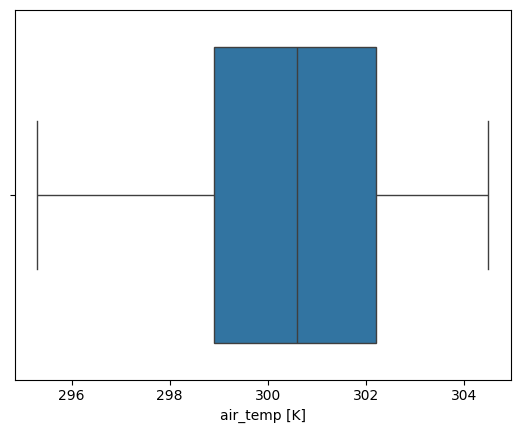

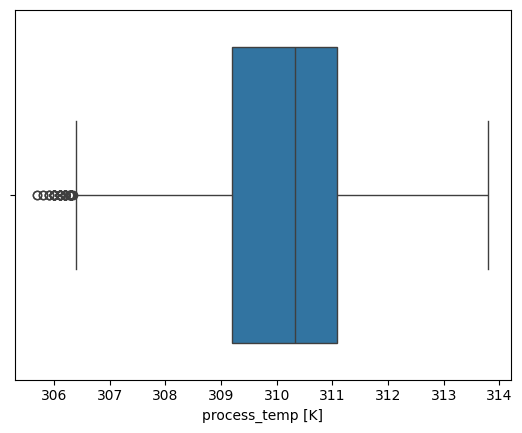

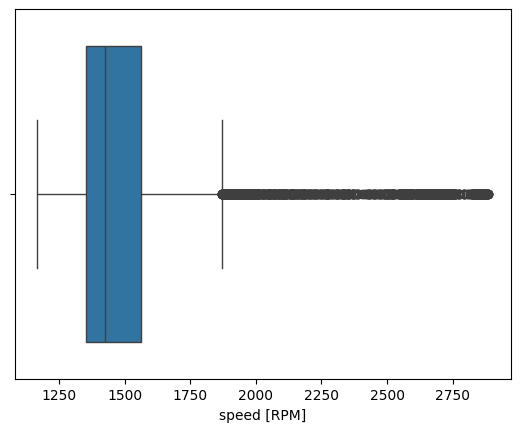

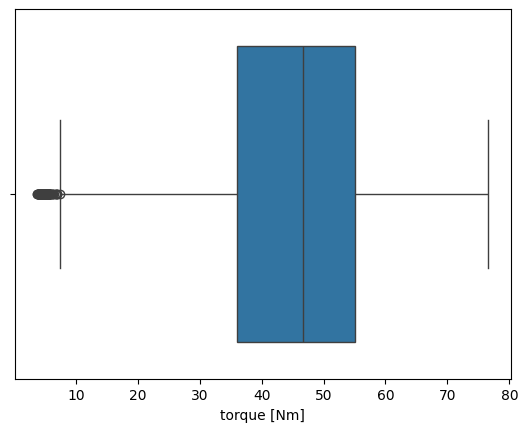

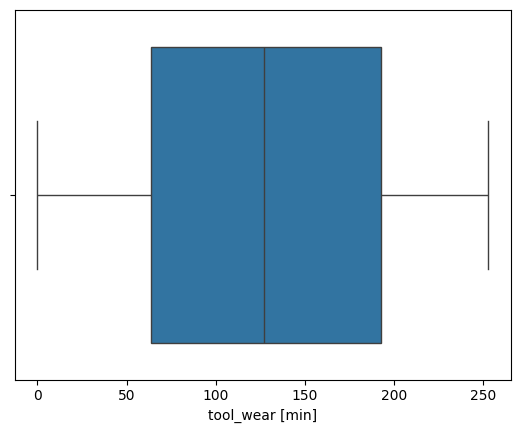

In [24]:
# Visualizamos valores atipicos
# Boxplot individual
import seaborn as sns

for col in cols:
    sns.boxplot(x=df[col])
    plt.show()

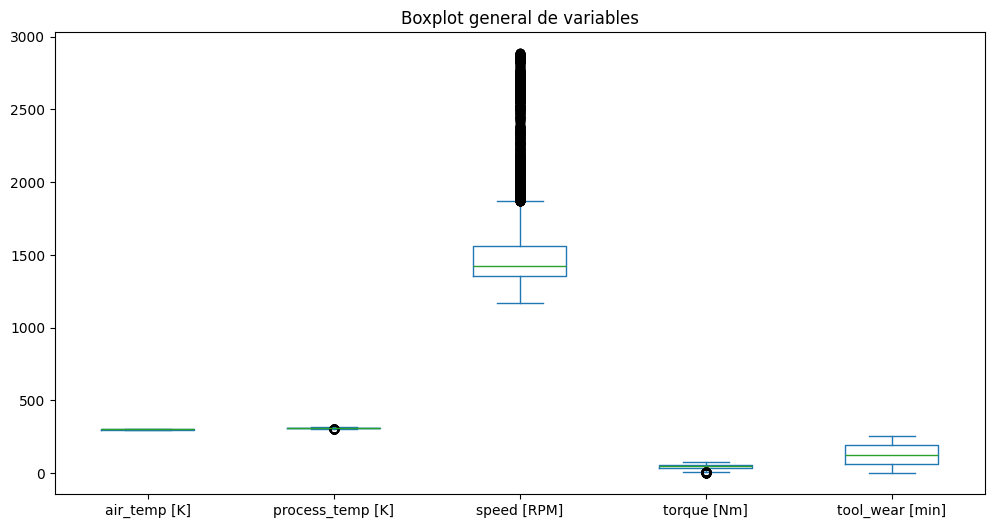

In [25]:
# Boxplot general
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
df[cols].plot(kind='box', figsize=(12,6))
plt.title("Boxplot general de variables")
plt.show()

Se utilizaron boxplots tanto de forma general como individual para analizar la presencia de valores atípicos en las variables numéricas. Se observan valores atipicos en speed, torque y process_temp.

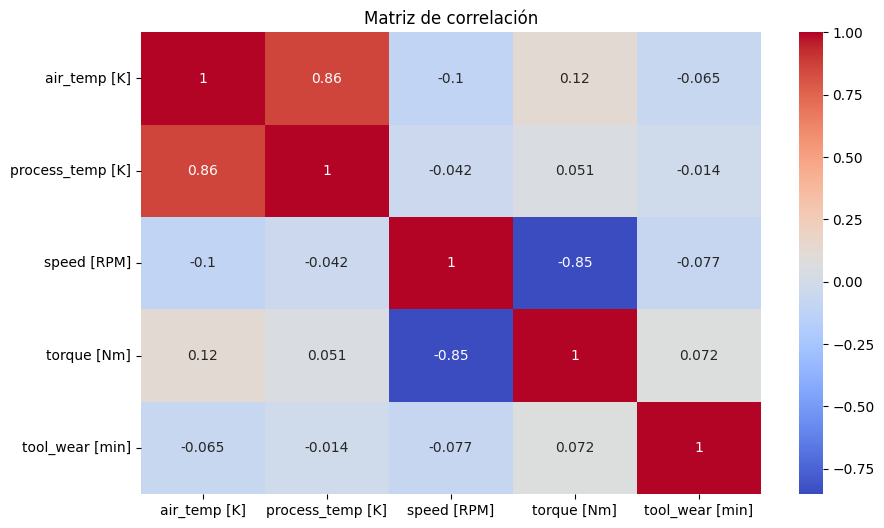

In [26]:
# Visualizamos la matriz de correlación de la columnas especificadas en cols
plt.figure(figsize=(10,6))

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Matriz de correlación")
plt.show()

In [27]:
# Procesamiento de var categóricas
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['product_type'] = le.fit_transform(df['product_type'])
df['target'] = le.fit_transform(df['target'])

df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,1,303.80,313.30,1406.0,52.10,166,1
1,1,3908,1,302.30,311.20,1633.0,36.40,114,1
2,2,10767,2,302.27,311.47,1228.0,68.75,187,0
3,3,15484,1,302.35,311.93,1522.0,36.99,214,0
4,4,784,1,296.70,307.90,1743.0,27.90,55,1


In [28]:
# Balance del conjunto de datos
# Visualizamos la cantidad de registros por clase en la variable objetivo
# Esto nos permite identificar si el dataset está desbalanceado
df['target'].value_counts()

,count
target,
0,7482
1,7039


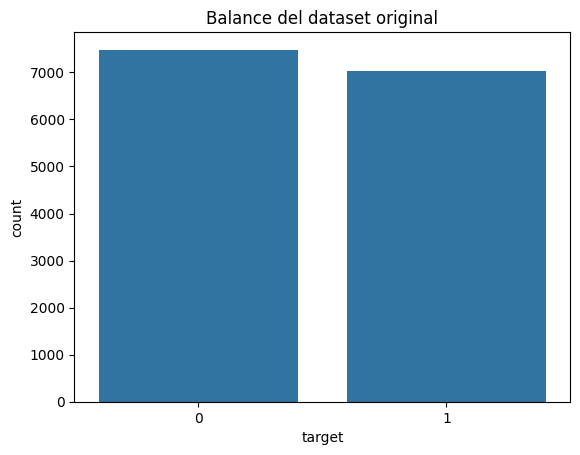

In [29]:
# Graficamos la distribución de la variable target
# Para ver visualmente si hay más casos de una clase que de otra
sns.countplot(x='target', data=df)
plt.title("Balance del dataset original")
plt.show()

In [30]:
# Separamos clases
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

In [32]:
# Aumentamos la cantidad de registros de la clase minoritaria
# Tomamos muestras con reemplazo hasta igualar la cantidad de la clase mayoritaria
df_minority_upsampled = df_minority.sample(
    n=len(df_majority),   # igualamos cantidad de filas
    replace=True,         # permite repetir filas
    random_state=42       # asegura reproducibilidad
)

In [33]:
# Unimos la clase mayoritaria con la minoritaria ya balanceada
df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [34]:
# Mezclamos las filas para evitar que queden ordenadas por clase
df_balanced = df_balanced.sample(frac=1, random_state=42)

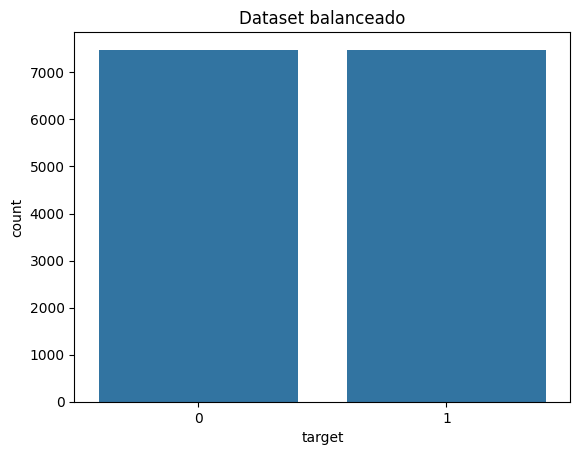

In [35]:
# Verificamos que ahora ambas clases tengan la misma cantidad
df_balanced['target'].value_counts()

# Visualizamos el nuevo balance con un gráfico
sns.countplot(x='target', data=df_balanced)
plt.title("Dataset balanceado")
plt.show()

In [36]:
# Normalización (Min-Max)

# Creamos una copia del dataset
df_normal = df_balanced.copy()

# Seleccionamos variables numéricas (sin target)
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

# Aplicamos normalización Min-Max
for col in cols:
    df_normal[col] = (df_normal[col] - df_normal[col].min()) / (df_normal[col].max() - df_normal[col].min())

# Verificamos
df_normal.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
603,603,7049,1,0.576087,0.580247,0.189756,0.597527,0.466403,1
2213,2213,17513,1,0.860870,0.730864,0.100116,0.653846,0.371542,0
4887,4887,12977,1,0.746739,0.592593,0.083236,0.705632,0.158103,0
9401,9401,12781,1,0.583696,0.537037,0.203143,0.557143,0.881423,0
1697,1697,134,1,0.380435,0.333333,0.116997,0.675824,0.545455,1


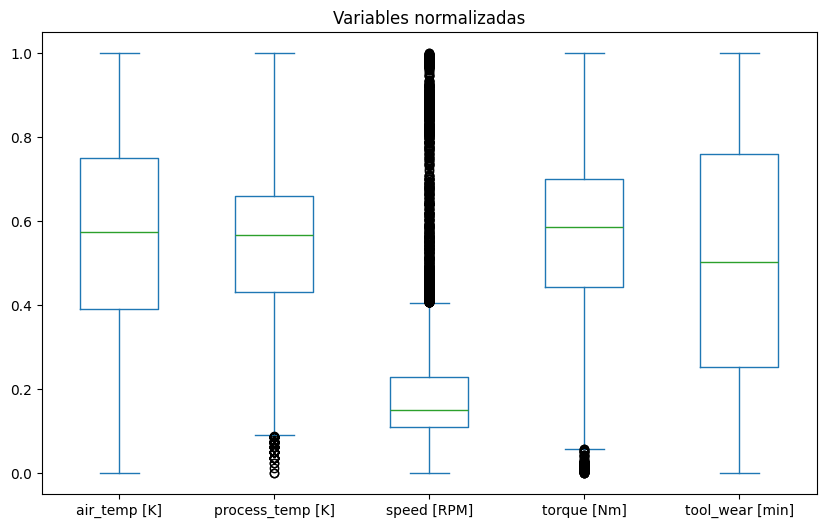

In [37]:
# Visualizamos
df_normal[cols].plot(kind='box', figsize=(10,6))
plt.title("Variables normalizadas")
plt.show()

In [38]:
# Preparación de datos para modelado

# Definimos las variables de entrada (X) y la variable objetivo (y)
X = df_normal.drop(columns=['target', 'idx', 'parent_device_id'])
y = df_normal['target']

# Verificamos dimensiones
print(X.shape)
print(y.shape)

(14964, 6)
(14964,)


In [39]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Mostramos tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10474, 6)
X_test: (4490, 6)
y_train: (10474,)
y_test: (4490,)


In [40]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Mostramos tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10474, 6)
X_test: (4490, 6)
y_train: (10474,)
y_test: (4490,)


Mejor KNN: KNeighborsClassifier(n_neighbors=3)
Accuracy train KNN: 0.9808096238304372
Accuracy test KNN: 0.9583518930957684
F1-score KNN: 0.9580246913580247
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2219
           1       0.98      0.94      0.96      2271

    accuracy                           0.96      4490
   macro avg       0.96      0.96      0.96      4490
weighted avg       0.96      0.96      0.96      4490



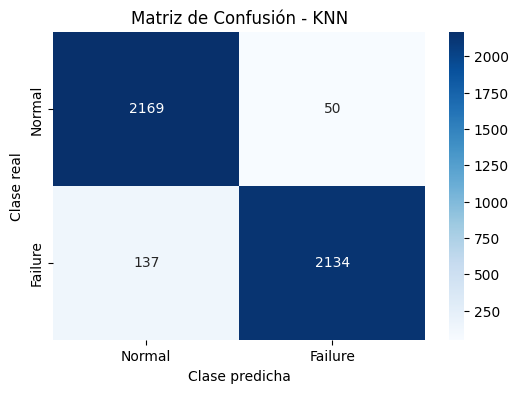

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos la grilla de hiperparámetros para KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

# Creamos el modelo con búsqueda en grilla
model_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5
)

# Entrenamos el modelo
model_knn.fit(X_train, y_train)

# Mostramos el mejor modelo encontrado
print("Mejor KNN:", model_knn.best_estimator_)

# Realizamos predicciones
y_pred_knn = model_knn.predict(X_test)

# Evaluamos
print("Accuracy train KNN:", model_knn.score(X_train, y_train))
print("Accuracy test KNN:", model_knn.score(X_test, y_test))
print("F1-score KNN:", f1_score(y_test, y_pred_knn))

# Reporte de clasificación
print(classification_report(y_test, y_pred_knn))

# Matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Matriz de Confusión - KNN')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()

Mejor Árbol: DecisionTreeClassifier(max_depth=9, max_features=5, random_state=42)
Accuracy train Árbol: 0.9678250907007829
Accuracy test Árbol: 0.9532293986636972
F1-score Árbol: 0.9538664323374341
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2219
           1       0.95      0.96      0.95      2271

    accuracy                           0.95      4490
   macro avg       0.95      0.95      0.95      4490
weighted avg       0.95      0.95      0.95      4490



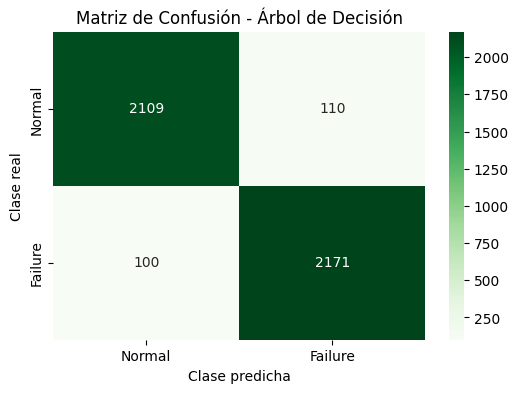

In [42]:
from sklearn.tree import DecisionTreeClassifier

# Definimos la grilla de hiperparámetros para Árbol de Decisión
param_grid_tree = {
    'max_depth': [3, 5, 7, 9],
    'max_features': [2, 3, 4, 5]
}

# Creamos el modelo con búsqueda en grilla
model_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=5
)

# Entrenamos
model_tree.fit(X_train, y_train)

# Mostramos el mejor modelo
print("Mejor Árbol:", model_tree.best_estimator_)

# Predicciones
y_pred_tree = model_tree.predict(X_test)

# Evaluación
print("Accuracy train Árbol:", model_tree.score(X_train, y_train))
print("Accuracy test Árbol:", model_tree.score(X_test, y_test))
print("F1-score Árbol:", f1_score(y_test, y_pred_tree))

# Reporte
print(classification_report(y_test, y_pred_tree))

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()

Mejor Random Forest: RandomForestClassifier(max_depth=8, max_features=4, random_state=42)
Accuracy train RF: 0.9653427534848196
Accuracy test RF: 0.9596881959910913
F1-score RF: 0.9597688375194487
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2219
           1       0.97      0.95      0.96      2271

    accuracy                           0.96      4490
   macro avg       0.96      0.96      0.96      4490
weighted avg       0.96      0.96      0.96      4490



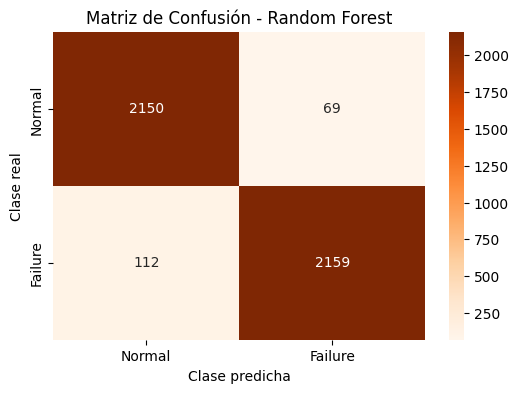

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Definimos la grilla de hiperparámetros para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'max_features': [2, 3, 4],
    'random_state': [42]
}

# Creamos el modelo con búsqueda en grilla
model_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid_rf,
    cv=5
)

# Entrenamos
model_rf.fit(X_train, y_train)

# Mostramos el mejor estimador
print("Mejor Random Forest:", model_rf.best_estimator_)

# Predicciones
y_pred_rf = model_rf.predict(X_test)

# Evaluación
print("Accuracy train RF:", model_rf.score(X_train, y_train))
print("Accuracy test RF:", model_rf.score(X_test, y_test))
print("F1-score RF:", f1_score(y_test, y_pred_rf))

# Reporte
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()